# Day 6 — 신호 구현 · 이벤트 스터디 · 순열검정

**기준 문서는 `docs/signal_spec.md` 하나다.** 명세에 없는 신호를 만들지 않고,
명세에 적힌 파라미터를 바꾸지 않는다. 오늘의 결과가 어떻게 나오든 §6 프로토콜과
§7 예측은 수정하지 않으며, 실측은 부록 C에 **추가**한다.

### 오늘의 순서

1. **Phase 1** — `src/signals.py` 검증 (NaN 패턴, 워밍업)
2. **Phase 2** — 사건 수 실측과 §7.1 예측 대조
3. **Phase 3** — 이벤트 스터디 (신호 5 × 지평 4 = 20조합)
4. **Phase 4** — 순열검정 ($B=10{,}000$, 시드 42, Bonferroni $\alpha_{adj}=0.0025$)

### 미리 못 박아두는 해석 규칙 (명세 §7.3, D5 로그)

| 상황 | 잘못된 결론 | 올바른 서술 |
|---|---|---|
| 전부 기각 | "전략이 실패했다" | "탐지 가능한 효과 크기가 아니었다 — 검정력 부족" |
| S3만 유의 | "조건부 임계선이 우월하다" | "$n$이 커서 탐지 문턱이 낮았다. 신호의 질과 무관" |
| S5 긴 지평이 유의 | "모멘텀이 살아있다" | "중첩 관측부터 의심" |
| 수익률이 높음 | 축하 | **미래 참조부터 의심** |

In [1]:
import sys
from importlib.metadata import version
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent  # -> Path (프로젝트 루트)
ROOT_TEXT = str(PROJECT_ROOT)     # -> str

if ROOT_TEXT not in sys.path:
    sys.path.insert(0, ROOT_TEXT)

from src import config, data, returns, signals

print(f"pandas : {pd.__version__}")
print(f"numpy  : {np.__version__}")
print(f"ta     : {version('ta')}")
print()
print("명세 §6 확정 프로토콜 (결과 열람 전 확정, 변경 금지)")
print(f"  지평            : {config.EVENT_HORIZONS}")
print(f"  최소 표본 수    : {config.MIN_EVENTS}")
print(f"  확증 검정 횟수 m: {config.CONFIRMATORY_TESTS}")
print(f"  Bonferroni      : {config.ALPHA} / {config.CONFIRMATORY_TESTS} = {config.ALPHA_ADJUSTED}")
print(f"  순열검정        : B={config.PERMUTATION_ITERATIONS:,}, 시드={config.PERMUTATION_SEED}, 양측")
print()
print("지표 규약 (명세 §3.3.2 — 기본값 금지)")
print(f"  RSI     : Wilder RMA, period={config.RSI_PERIOD}, seed={config.WILDER_SEED!r}")
print(f"  볼린저  : SMA, window={config.BB_PERIOD}, k={config.BB_NUM_STD}, ddof={config.BB_STD_DDOF}")
print(f"  MACD    : EMA {config.MACD_FAST}/{config.MACD_SLOW}/{config.MACD_SIGNAL}, adjust={config.EWM_ADJUST}")

pandas : 3.0.5
numpy  : 2.5.1
ta     : 0.11.0

명세 §6 확정 프로토콜 (결과 열람 전 확정, 변경 금지)
  지평            : [1, 5, 10, 20]
  최소 표본 수    : 30
  확증 검정 횟수 m: 20
  Bonferroni      : 0.05 / 20 = 0.0025
  순열검정        : B=10,000, 시드=42, 양측

지표 규약 (명세 §3.3.2 — 기본값 금지)
  RSI     : Wilder RMA, period=14, seed='sma'
  볼린저  : SMA, window=20, k=2.0, ddof=0
  MACD    : EMA 12/26/9, adjust=False


## Phase 1 — 신호 구현 검증

### 1-1. 지표 NaN 패턴 육안 확인 (명세 §3.3.3-3)

D4에서 `ta`의 ATR이 워밍업을 NaN이 아니라 `0.0`으로 채우는 것을 발견했다.
**"계산 불가"가 "값이 0"으로 둔갑하면 신호 로직이 조용히 오염된다.**
같은 사고를 막기 위해 지표 계산 직후 앞 50행을 눈으로 확인한다.

In [2]:
df = data.load_parquet(config.RAW_OHLCV_PATH)  # -> DataFrame (18424, 8)

indicator_frame = signals.add_indicators(df)  # -> DataFrame (18424, 17)

signal_ticker = config.TICKERS["signal"]                       # -> str ("^GSPC")
ticker_mask = indicator_frame["ticker"] == signal_ticker       # -> Series[bool] (18424,)
signal_rows = indicator_frame.loc[ticker_mask]                 # -> DataFrame (9212, 17)
signal_rows = signal_rows.sort_values("date")                  # -> DataFrame
signal_rows = signal_rows.reset_index(drop=True)               # -> DataFrame

check_columns = [
    "date",
    f"rsi_wilder_{config.RSI_PERIOD}",
    "bb_lower",
    "bb_upper",
    "macd_line",
    "macd_signal",
]  # -> list[str] (6,)

head_view = signal_rows[check_columns].head(50)  # -> DataFrame (50, 6)

print("앞 50행 NaN 패턴 (True = NaN)")
nan_pattern = head_view.isna()                    # -> DataFrame (50, 6) bool
nan_counts = nan_pattern.sum()                    # -> Series[int] (6,)
print(nan_counts.to_string())
print()
print("각 지표의 첫 유효 인덱스 (명세 §3.3.2 워밍업과 대조)")
expected_warmup = {
    f"rsi_wilder_{config.RSI_PERIOD}": config.RSI_PERIOD,
    "bb_lower": config.BB_PERIOD - 1,
    "bb_upper": config.BB_PERIOD - 1,
    "macd_line": config.MACD_SLOW - 1,
    "macd_signal": config.MACD_SLOW - 1 + config.MACD_SIGNAL - 1,
}  # -> dict[str, int] (5,)

for column_name in expected_warmup:
    column = signal_rows[column_name]              # -> Series[float] (9212,)
    first_valid = column.first_valid_index()       # -> int
    expected = expected_warmup[column_name]        # -> int
    status = "OK" if first_valid == expected else "확인 필요"
    print(f"  {column_name:<18} 첫 유효 idx={first_valid:<4} 규약={expected:<4} {status}")

2026-08-08 01:56:30,355 [INFO] 로드 완료: C:\Users\chris\projects\sp500-technical-strategy\data\raw\ohlcv_raw.parquet (18424행)


앞 50행 NaN 패턴 (True = NaN)
date              0
rsi_wilder_14    14
bb_lower         19
bb_upper         19
macd_line        25
macd_signal      33

각 지표의 첫 유효 인덱스 (명세 §3.3.2 워밍업과 대조)
  rsi_wilder_14      첫 유효 idx=14   규약=14   OK
  bb_lower           첫 유효 idx=19   규약=19   OK
  bb_upper           첫 유효 idx=19   규약=19   OK
  macd_line          첫 유효 idx=25   규약=25   OK
  macd_signal        첫 유효 idx=33   규약=33   OK


In [3]:
# 분석 구간(2000-01-01 이후)에 지표 NaN이 하나라도 있으면 에러로 처리한다.
# 명세 §3.3.3-2: 조용히 dropna() 하지 않는다. 1990년부터 10년치 워밍업을
# 확보해 두었으므로 분석 구간 시작부에 NaN이 있을 이유가 없다.

analysis_start = pd.Timestamp(config.ANALYSIS_START)         # -> Timestamp
in_analysis = signal_rows["date"] >= analysis_start          # -> Series[bool] (9212,)
analysis_rows = signal_rows.loc[in_analysis]                 # -> DataFrame (6684, 17)

indicator_columns = list(expected_warmup.keys())             # -> list[str] (5,)
analysis_nan = analysis_rows[indicator_columns].isna().sum()  # -> Series[int] (5,)

print(f"분석 구간 {config.ANALYSIS_START} ~ , 행 수 {len(analysis_rows):,}")
print()
print("분석 구간 지표 NaN 개수 (전부 0이어야 함)")
print(analysis_nan.to_string())

total_nan = int(analysis_nan.sum())  # -> int

if total_nan > 0:
    raise ValueError(
        f"분석 구간에 지표 NaN이 {total_nan}개 있다. "
        "원인을 규명하기 전에는 진행하지 않는다 (명세 §3.3.3-2)."
    )

print()
print("=> 통과. 워밍업이 분석 구간 이전에 모두 끝났다.")

분석 구간 2000-01-01 ~ , 행 수 6,684

분석 구간 지표 NaN 개수 (전부 0이어야 함)
rsi_wilder_14    0
bb_lower         0
bb_upper         0
macd_line        0
macd_signal      0

=> 통과. 워밍업이 분석 구간 이전에 모두 끝났다.


### 1-2. 엣지 변환 동작 확인 (명세 §3.2)

$s_t = c_t \wedge \neg c_{t-1}$ — 조건이 **거짓에서 참으로 전환된 첫날만** 센다.

In [4]:
# 인공 데이터로 엣지 변환을 확인한다.
sample_condition = pd.Series([False, True, True, True, False, True, False])  # -> Series[bool] (7,)
sample_edge = signals.to_edge(sample_condition)                              # -> Series[bool] (7,)

comparison = pd.DataFrame(
    {
        "조건 c_t": sample_condition,
        "엣지 s_t": sample_edge,
    }
)  # -> DataFrame (7, 2)

print("엣지 변환 동작")
print(comparison.to_string())
print()
print("  3일 연속 참(idx 1~3)은 사건 1개다. idx 2, 3은 사건이 아니다.")
print("  첫 행은 c_{-1} = False 로 간주하므로, 첫날이 참이면 사건으로 센다.")
print()

expected = [False, True, False, False, False, True, False]  # -> list[bool] (7,)
matched = sample_edge.tolist() == expected                   # -> bool
print(f"  기대값과 일치: {matched}")

엣지 변환 동작
   조건 c_t  엣지 s_t
0   False   False
1    True    True
2    True   False
3    True   False
4   False   False
5    True    True
6   False   False

  3일 연속 참(idx 1~3)은 사건 1개다. idx 2, 3은 사건이 아니다.
  첫 행은 c_{-1} = False 로 간주하므로, 첫날이 참이면 사건으로 센다.

  기대값과 일치: True


In [5]:
# 신호 생성 후 parquet으로 별도 저장 (명세 §4.0)
# 신호 생성과 실행을 분리해 두어야 2단계에서 같은 신호를 다른 엔진에 넣는
# 실험이 가능하다.

signal_frame = signals.make_signals(df)  # -> DataFrame (92120, 5)

print(f"신호 프레임: {signal_frame.shape}")
print(f"신호 종류  : {sorted(signal_frame['signal_id'].unique())}")
print()

saved = signal_frame[["date", "ticker", "signal_id", "signal"]]  # -> DataFrame (92120, 4)
saved.to_parquet(config.SIGNALS_PARQUET_PATH, index=False)
print(f"저장 완료: {config.SIGNALS_PARQUET_PATH}")
print("  (data/ 는 gitignore 대상이므로 커밋되지 않는다 — 코드로 재생성 가능)")

신호 프레임: (92120, 5)
신호 종류  : ['S1_rsi_oversold', 'S2_rsi_overbought', 'S3_bb_lower_break', 'S4_bb_upper_break', 'S5_macd_cross']

저장 완료: C:\Users\chris\projects\sp500-technical-strategy\data\processed\signals.parquet
  (data/ 는 gitignore 대상이므로 커밋되지 않는다 — 코드로 재생성 가능)


## Phase 2 — 사건 수 실측과 예측 대조

**§7의 예측값은 수정하지 않는다.** 실측을 나란히 놓고 부록 C에 기록할 뿐이다
(명세 부록 A: "조용히 수정하면 사전등록이 아니게 된다").

In [6]:
forward_frame = signals.forward_returns(df)                              # -> DataFrame (18424, 13)
merged = signals.attach_forward_returns(signal_frame, forward_frame)     # -> DataFrame (92120, 11)

analysis_mask = merged["date"] >= analysis_start          # -> Series[bool]
ticker_mask_signal = merged["ticker"] == signal_ticker    # -> Series[bool]
events = merged.loc[analysis_mask & ticker_mask_signal]   # -> DataFrame (33420, 11)
events = events.reset_index(drop=True)                    # -> DataFrame

universe_mask = forward_frame["ticker"] == signal_ticker                  # -> Series[bool]
universe = forward_frame.loc[universe_mask]                              # -> DataFrame (9212, 13)
universe = universe.loc[universe["date"] >= analysis_start]              # -> DataFrame (6684, 13)
universe = universe.sort_values("date")                                  # -> DataFrame
universe = universe.reset_index(drop=True)                               # -> DataFrame

total_days = len(universe)  # -> int
print(f"분석 구간 거래일: {total_days:,}")

분석 구간 거래일: 6,684


In [7]:
# 사전등록된 예측값 (명세 부록 C-1). 여기서 값을 바꾸지 않는다.
PREDICTION_SELF = {
    "S1_rsi_oversold": 76,
    "S2_rsi_overbought": 234,
    "S3_bb_lower_break": 217,
    "S4_bb_upper_break": 239,
    "S5_macd_cross": 1003,
}  # -> dict[str, int] (5,)

PREDICTION_REFERENCE = {
    "S1_rsi_oversold": 42,
    "S2_rsi_overbought": 61,
    "S3_bb_lower_break": 186,
    "S4_bb_upper_break": 184,
    "S5_macd_cross": 197,
}  # -> dict[str, int] (5,)

count_rows = []  # -> list[dict]

for signal_id, label, _condition_function in signals.SIGNAL_DEFINITIONS:
    subset = events.loc[events["signal_id"] == signal_id]  # -> DataFrame (6684, 11)

    level_days = int(subset["condition"].sum())   # -> int, 엣지 변환 **전**
    event_count = int(subset["signal"].sum())     # -> int, 엣지 변환 **후**

    level_rate = 100 * level_days / total_days    # -> float

    if event_count > 0:
        mean_duration = level_days / event_count  # -> float
    else:
        mean_duration = float("nan")              # -> float

    count_rows.append(
        {
            "signal_id": signal_id,
            "label": label,
            "레벨 일수": level_days,
            "레벨 발동률%": level_rate,
            "사건 수 n": event_count,
            "평균 지속일수": mean_duration,
            "예측(본인)": PREDICTION_SELF[signal_id],
            "예측(참고)": PREDICTION_REFERENCE[signal_id],
            "본인 대비 배율": event_count / PREDICTION_SELF[signal_id],
            "참고 대비 배율": event_count / PREDICTION_REFERENCE[signal_id],
        }
    )

count_table = pd.DataFrame(count_rows)  # -> DataFrame (5, 10)
count_table.to_csv(config.SIGNAL_COUNTS_CSV_PATH, index=False, encoding="utf-8-sig")

show = ["label", "레벨 일수", "레벨 발동률%", "사건 수 n", "평균 지속일수",
        "예측(본인)", "본인 대비 배율", "예측(참고)", "참고 대비 배율"]
count_table[show].round(3)

,label,레벨 일수,레벨 발동률%,사건 수 n,평균 지속일수,예측(본인),본인 대비 배율,예측(참고),참고 대비 배율
0,S1 RSI<30,126,1.885,65,1.938,76,0.855,42,1.548
1,S2 RSI>70,426,6.373,137,3.109,234,0.585,61,2.246
2,S3 볼린저 하단,368,5.506,209,1.761,217,0.963,186,1.124
3,S4 볼린저 상단,321,4.803,191,1.681,239,0.799,184,1.038
4,S5 MACD>Signal,3360,50.269,283,11.873,1003,0.282,197,1.437


In [8]:
# 지속일수 분포 — 평균만 보면 꼬리가 안 보인다.
print("조건 연속 유지 구간(런) 길이 분포")
print(f"{'신호':<16}{'런 수':>7}{'평균':>8}{'중앙값':>8}{'p90':>7}{'최대':>7}")

for signal_id, label, _fn in signals.SIGNAL_DEFINITIONS:
    subset = events.loc[events["signal_id"] == signal_id]  # -> DataFrame
    subset = subset.sort_values("date")                     # -> DataFrame

    condition_values = subset["condition"].to_numpy()  # -> ndarray[bool] (6684,)

    run_lengths = []  # -> list[int]
    current = 0       # -> int

    for value in condition_values:
        if value:
            current = current + 1
        elif current > 0:
            run_lengths.append(current)
            current = 0

    if current > 0:
        run_lengths.append(current)

    runs = np.array(run_lengths)  # -> ndarray[int]

    print(f"{label:<16}{len(runs):>7}{runs.mean():>8.2f}{np.median(runs):>8.1f}"
          f"{np.percentile(runs, 90):>7.1f}{runs.max():>7}")

print()
print("주의: 런 수와 사건 수가 1 차이 나는 신호가 있을 수 있다.")
print("신호는 1990년부터 계산한 뒤 분석 구간을 잘라내므로, 2000-01-01 이전에")
print("시작된 런은 그 전환일이 구간 밖이라 사건으로 세어지지 않는다. 정상 동작이다.")

조건 연속 유지 구간(런) 길이 분포
신호                  런 수      평균     중앙값    p90     최대
S1 RSI<30            65    1.94     1.0    3.6      9
S2 RSI>70           137    3.11     2.0    6.0     18
S3 볼린저 하단           209    1.76     1.0    4.0      7
S4 볼린저 상단           191    1.68     1.0    3.0      6
S5 MACD>Signal      284   11.83    10.0   24.0     39

주의: 런 수와 사건 수가 1 차이 나는 신호가 있을 수 있다.
신호는 1990년부터 계산한 뒤 분석 구간을 잘라내므로, 2000-01-01 이전에
시작된 런은 그 전환일이 구간 밖이라 사건으로 세어지지 않는다. 정상 동작이다.


### S5 sanity check (명세 §7.1)

> "S5 레벨 발동률이 50%에서 크게 벗어나면 시장 특성이 아니라 **계산 오류를
> 의심할 신호**다. 단 어긋났을 때 즉시 코드를 의심하지 말고 **MACD 값 자체의
> 분포를 먼저 확인**한다."

"틀리면 코드를 의심해야 하는 예측"을 미리 만들어둔 것이 sanity check의
사전등록 버전이다.

In [9]:
s5_row = count_table.loc[count_table["signal_id"] == "S5_macd_cross"]  # -> DataFrame (1, 10)
s5_rate = float(s5_row["레벨 발동률%"].iloc[0])                          # -> float

print(f"S5 레벨 발동률 (MACD > Signal): {s5_rate:.2f}%")
print(f"  판정 범위 45~55% -> {'정상' if 45 <= s5_rate <= 55 else '이탈, MACD 분포 확인 필요'}")
print()

# 어긋나든 아니든 MACD 값 자체의 분포는 확인해 근거를 남긴다.
macd_series = analysis_rows["macd_line"].dropna()  # -> Series[float] (6684,)

print("MACD 값 자체의 분포 (Signal 대비가 아니라 절대값)")
print(f"  양수 비율 : {100 * (macd_series > 0).mean():.2f}%")
print(f"  중앙값    : {macd_series.median():.3f}")
print(f"  평균      : {macd_series.mean():.3f}")
print()
print("해석: MACD 절대값은 양수 쪽으로 치우쳐 있다(26년 우상향 시장이므로 당연하다).")
print("그런데 Signal 대비 위치는 50%에 수렴한다. Signal이 MACD 자신의 9일 EMA이므로")
print("MACD가 어느 수준에 있든 자기 평균 위아래를 반반씩 지나기 때문이다.")
print("=> 두 분포가 다른 것이 정상이며, 계산 오류의 징후가 아니다.")

S5 레벨 발동률 (MACD > Signal): 50.27%
  판정 범위 45~55% -> 정상

MACD 값 자체의 분포 (Signal 대비가 아니라 절대값)
  양수 비율 : 65.75%
  중앙값    : 6.897
  평균      : 6.335

해석: MACD 절대값은 양수 쪽으로 치우쳐 있다(26년 우상향 시장이므로 당연하다).
그런데 Signal 대비 위치는 50%에 수렴한다. Signal이 MACD 자신의 9일 EMA이므로
MACD가 어느 수준에 있든 자기 평균 위아래를 반반씩 지나기 때문이다.
=> 두 분포가 다른 것이 정상이며, 계산 오류의 징후가 아니다.


In [10]:
# 국면별 사건 수 (명세 §6.2 — 사후 분석 전용)
phased_events = returns.tag_phase(events)  # -> DataFrame (33420, 12)

fired = phased_events.loc[phased_events["signal"]]  # -> DataFrame (사건 수 합계, 12)

phase_counts = pd.crosstab(fired["signal_id"], fired["phase"])  # -> DataFrame (5, 6)

phase_order = [key for key in config.MARKET_REGIMES if key in phase_counts.columns]
phase_counts = phase_counts[phase_order]  # -> DataFrame (5, 6), 연대순

phase_counts.columns = [config.MARKET_REGIMES[key]["name"] for key in phase_order]

print("국면별 사건 수 (명세 §6.3: n < 30 이면 통계적 주장을 하지 않는다)")
print()
display_counts = phase_counts.copy()  # -> DataFrame (5, 6)
display_counts.index = [signals.SIGNAL_NAMES[i] for i in display_counts.index]
display_counts

국면별 사건 수 (명세 §6.3: n < 30 이면 통계적 주장을 하지 않는다)

,닷컴 붕괴,회복·확장,금융위기,장기 강세,코로나,최근 국면
S1 RSI<30,15,7,9,21,3,10
S2 RSI>70,2,19,0,78,2,36
S3 볼린저 하단,40,25,20,74,4,46
S4 볼린저 상단,11,40,4,79,5,52
S5 MACD>Signal,29,57,11,114,5,67


In [11]:
# n >= 30 을 통과하는 칸 수 (§7.3 질문 3 대조)
passing_cells = int((phase_counts >= config.MIN_EVENTS).sum().sum())  # -> int
total_cells = phase_counts.size                                       # -> int

print(f"n >= {config.MIN_EVENTS} 통과 칸: {passing_cells} / {total_cells}"
      f" ({100 * passing_cells / total_cells:.1f}%)")
print(f"  §7.3 질문3 예측: 7~11칸 (약 25~35%)")

n >= 30 통과 칸: 11 / 30 (36.7%)
  §7.3 질문3 예측: 7~11칸 (약 25~35%)


## Phase 3 — 이벤트 스터디

명세 §6.7의 보고 항목을 전부 산출한다. **전체 표본 평균과의 차이가 실질적
관심 대상**이다 — 절대 수익률은 시장이 우상향했다는 사실만 반영한다.

In [12]:
# 먼저 전체 표본의 지평별 통계. §7.3의 20일 표준편차 가정 5.4%와 대조한다.
print("전체 표본 (무작위 진입 기준선)")
print(f"{'h':>3}{'n':>7}{'평균%':>9}{'표준편차%':>11}")

baseline = {}  # -> dict[int, dict]

for horizon in config.EVENT_HORIZONS:
    column_name = f"fwd_ret_{horizon}"        # -> str
    values = universe[column_name].dropna()    # -> Series[float]

    baseline[horizon] = {
        "n": len(values),
        "mean": float(values.mean()),
        "std": float(values.std()),
    }

    print(f"{horizon:>3}{len(values):>7}{100 * values.mean():>9.3f}{100 * values.std():>11.3f}")

assumed_std = 5.4                                  # -> float, §7.3 가정값 (%)
actual_std = 100 * baseline[20]["std"]             # -> float

print()
print(f"§7.3 검정력 계산의 20일 표준편차 가정: {assumed_std}%")
print(f"실측 20일 표준편차                  : {actual_std:.2f}%")
print(f"가정 / 실측 = {assumed_std / actual_std:.3f}배")
print()
print("가정이 실측보다 크므로 §7.3의 '필요 초과수익'은 **과대** 추정이었다.")
print("즉 실제 탐지 문턱은 계산보다 낮다 — 이 방향의 오차는 신호에 유리하다.")

전체 표본 (무작위 진입 기준선)
  h      n      평균%      표준편차%
  1   6682    0.032      1.213
  5   6678    0.154      2.453
 10   6673    0.303      3.309
 20   6663    0.609      4.604

§7.3 검정력 계산의 20일 표준편차 가정: 5.4%
실측 20일 표준편차                  : 4.60%
가정 / 실측 = 1.173배

가정이 실측보다 크므로 §7.3의 '필요 초과수익'은 **과대** 추정이었다.
즉 실제 탐지 문턱은 계산보다 낮다 — 이 방향의 오차는 신호에 유리하다.


In [13]:
event_rows = []  # -> list[dict]

for signal_id, label, _fn in signals.SIGNAL_DEFINITIONS:
    fired_subset = events.loc[
        (events["signal_id"] == signal_id) & (events["signal"])
    ]  # -> DataFrame (사건 수, 11)

    for horizon in config.EVENT_HORIZONS:
        column_name = f"fwd_ret_{horizon}"                # -> str
        values = fired_subset[column_name].dropna()        # -> Series[float]

        if len(values) == 0:
            continue

        universe_mean = baseline[horizon]["mean"]  # -> float

        event_rows.append(
            {
                "signal_id": signal_id,
                "label": label,
                "h": horizon,
                "n": len(values),
                "평균%": 100 * float(values.mean()),
                "중앙값%": 100 * float(values.median()),
                "표준편차%": 100 * float(values.std()),
                "승률%": 100 * float((values > 0).mean()),
                "전체평균%": 100 * universe_mean,
                "차이%p": 100 * (float(values.mean()) - universe_mean),
            }
        )

event_table = pd.DataFrame(event_rows)  # -> DataFrame (20, 10)
event_table.to_csv(config.EVENT_STUDY_CSV_PATH, index=False, encoding="utf-8-sig")

event_table.round(3)

,signal_id,label,h,n,평균%,중앙값%,표준편차%,승률%,전체평균%,차이%p
0,S1_rsi_oversold,S1 RSI<30,1,65,-0.470,-0.130,2.599,47.692,0.032,-0.502
1,S1_rsi_oversold,S1 RSI<30,5,65,-0.043,0.600,4.348,60.000,0.154,-0.198
2,S1_rsi_oversold,S1 RSI<30,10,65,0.276,0.175,5.050,52.308,0.303,-0.026
3,S1_rsi_oversold,S1 RSI<30,20,65,1.797,1.867,6.716,64.615,0.609,1.188
4,S2_rsi_overbought,S2 RSI>70,1,137,0.006,0.045,0.613,52.555,0.032,-0.026
5,S2_rsi_overbought,S2 RSI>70,5,137,0.129,0.267,1.198,59.124,0.154,-0.025
6,S2_rsi_overbought,S2 RSI>70,10,137,0.395,0.644,1.819,68.613,0.303,0.092
7,S2_rsi_overbought,S2 RSI>70,20,137,0.917,1.484,2.926,72.263,0.609,0.308
8,S3_bb_lower_break,S3 볼린저 하단,1,209,-0.017,0.294,1.852,55.502,0.032,-0.049
9,S3_bb_lower_break,S3 볼린저 하단,5,208,0.216,0.414,3.713,56.250,0.154,0.062


### 그림 — 지평별 초과수익 곡선

**X2 확정에 직접 쓰이는 그림이다** (명세 §5.2). S1의 사후 수익률이 어느 지평에서
정점을 찍는지가 청산 조건을 가른다.

그림 저장: C:\Users\chris\projects\sp500-technical-strategy\figures\day06_horizon_curves.png


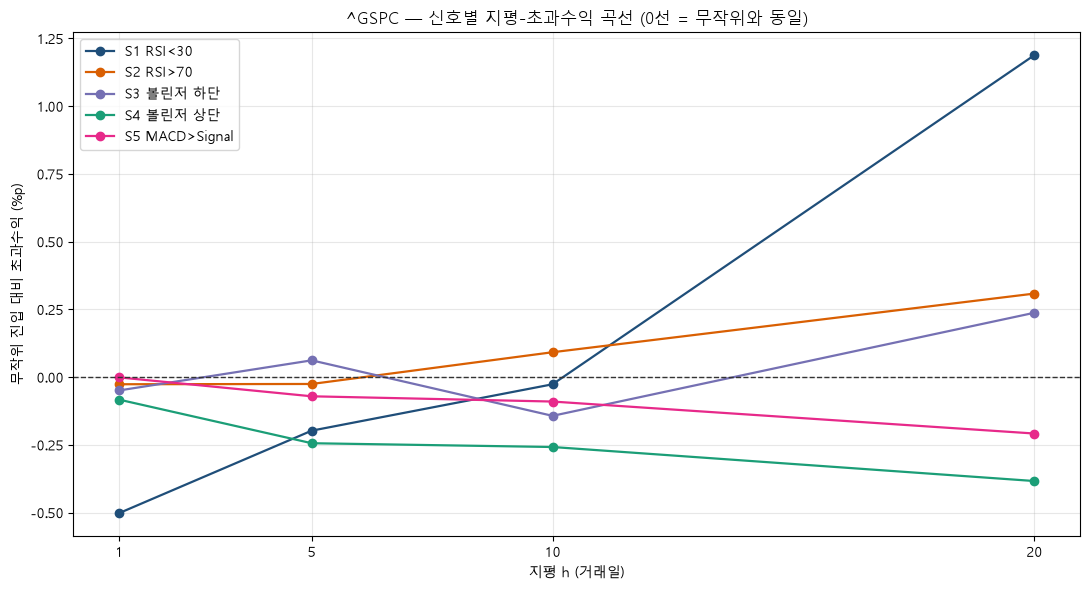

In [14]:
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.family"] = "Malgun Gothic"  # 윈도우 한글 폰트
matplotlib.rcParams["axes.unicode_minus"] = False     # 한글 폰트에 유니코드 마이너스 글리프가 없다

figure, axes = plt.subplots(figsize=(11, 6))

colors = ["#1f4e79", "#d95f02", "#7570b3", "#1b9e77", "#e7298a"]  # -> list[str] (5,)

for position, (signal_id, label, _fn) in enumerate(signals.SIGNAL_DEFINITIONS):
    subset = event_table.loc[event_table["signal_id"] == signal_id]  # -> DataFrame (4, 10)
    subset = subset.sort_values("h")                                  # -> DataFrame

    axes.plot(
        subset["h"],
        subset["차이%p"],
        marker="o",
        linewidth=1.6,
        color=colors[position],
        label=label,
    )

axes.axhline(0, color="#333333", linewidth=1.0, linestyle="--")
axes.set_xlabel("지평 h (거래일)")
axes.set_ylabel("무작위 진입 대비 초과수익 (%p)")
axes.set_title(f"{signal_ticker} — 신호별 지평-초과수익 곡선 (0선 = 무작위와 동일)")
axes.set_xticks(config.EVENT_HORIZONS)
axes.grid(alpha=0.3)
axes.legend()

figure.tight_layout()
figure.savefig(config.FIGURES / "day06_horizon_curves.png",
               dpi=config.FIGURE_DPI, bbox_inches=config.FIGURE_BBOX)
print(f"그림 저장: {config.FIGURES / 'day06_horizon_curves.png'}")

plt.show()

그림 저장: C:\Users\chris\projects\sp500-technical-strategy\figures\event_study_S1_rsi_oversold.png


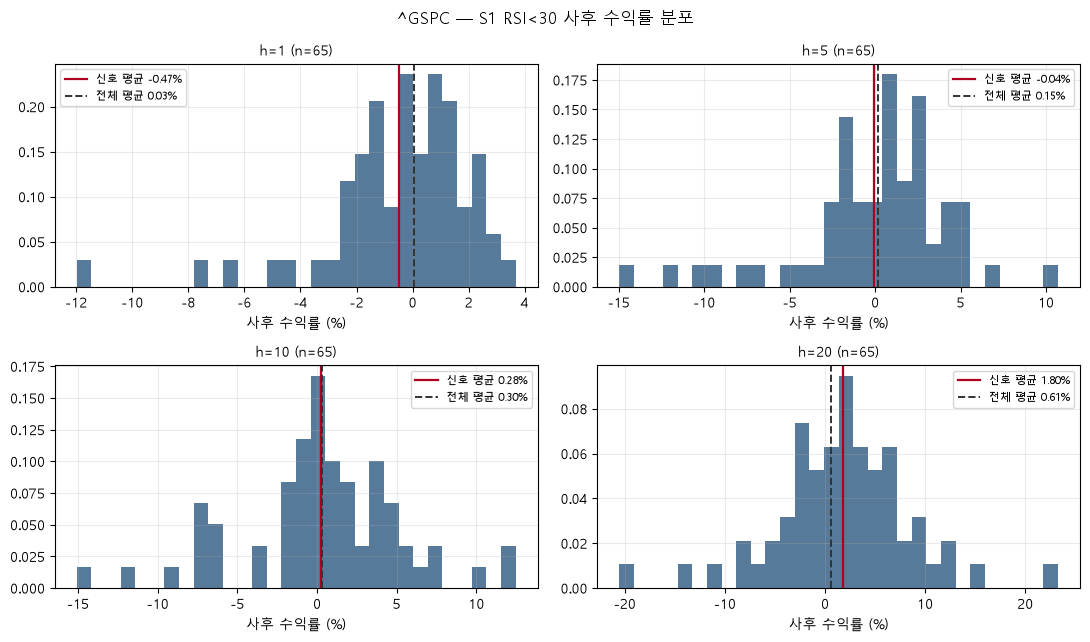

그림 저장: C:\Users\chris\projects\sp500-technical-strategy\figures\event_study_S2_rsi_overbought.png


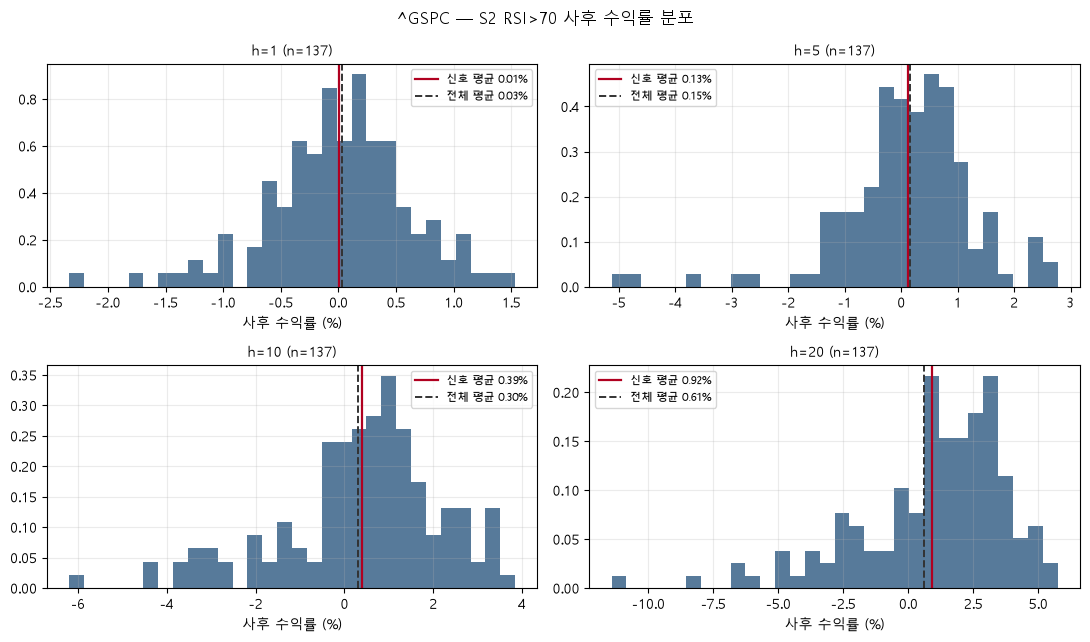

그림 저장: C:\Users\chris\projects\sp500-technical-strategy\figures\event_study_S3_bb_lower_break.png


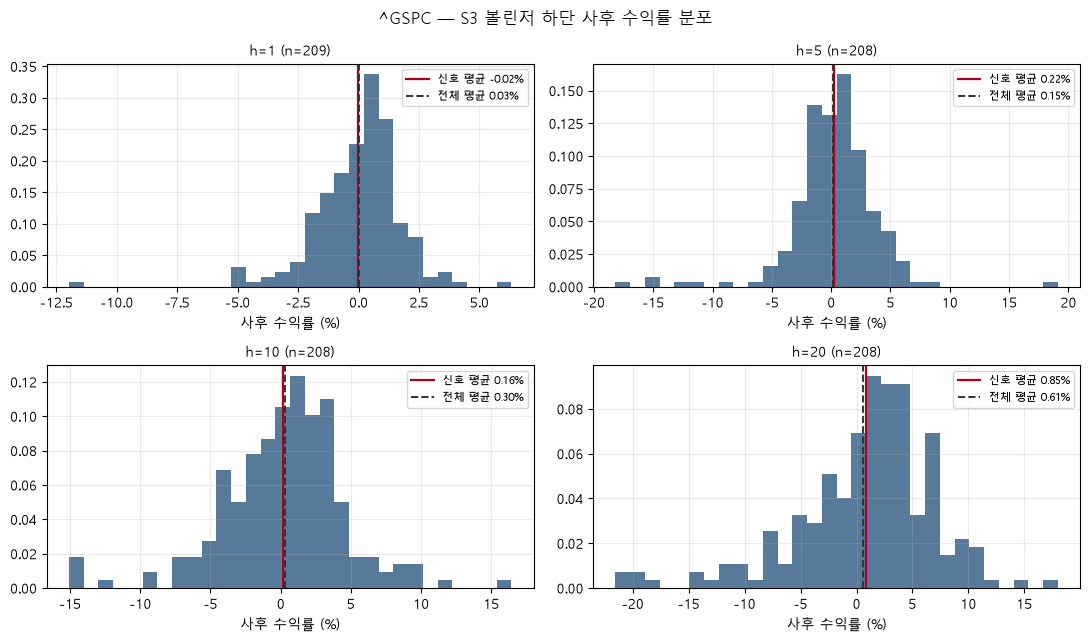

그림 저장: C:\Users\chris\projects\sp500-technical-strategy\figures\event_study_S4_bb_upper_break.png


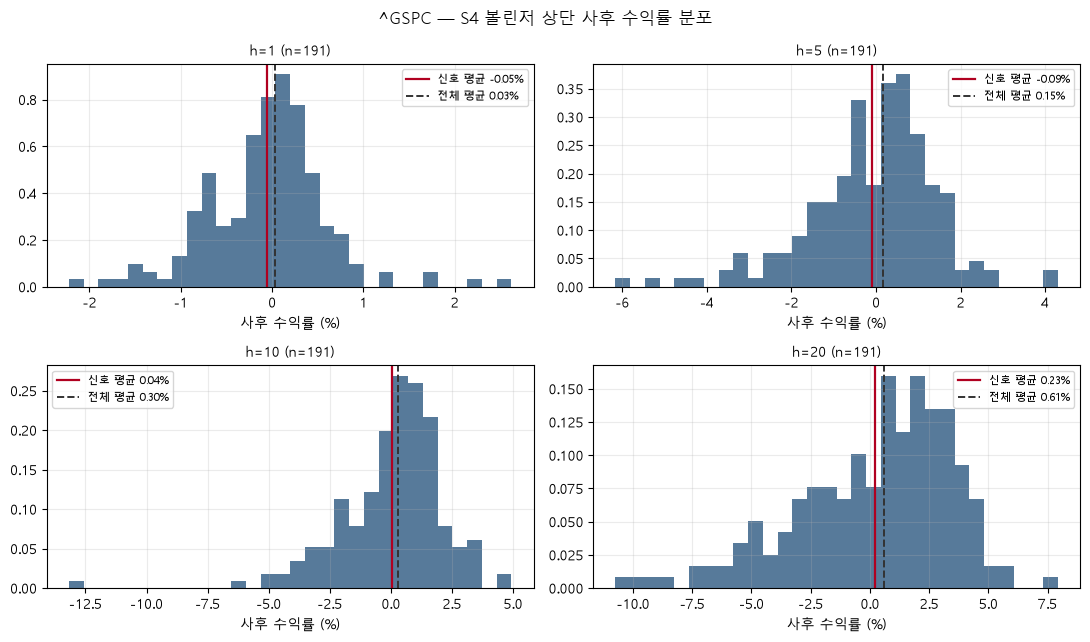

그림 저장: C:\Users\chris\projects\sp500-technical-strategy\figures\event_study_S5_macd_cross.png


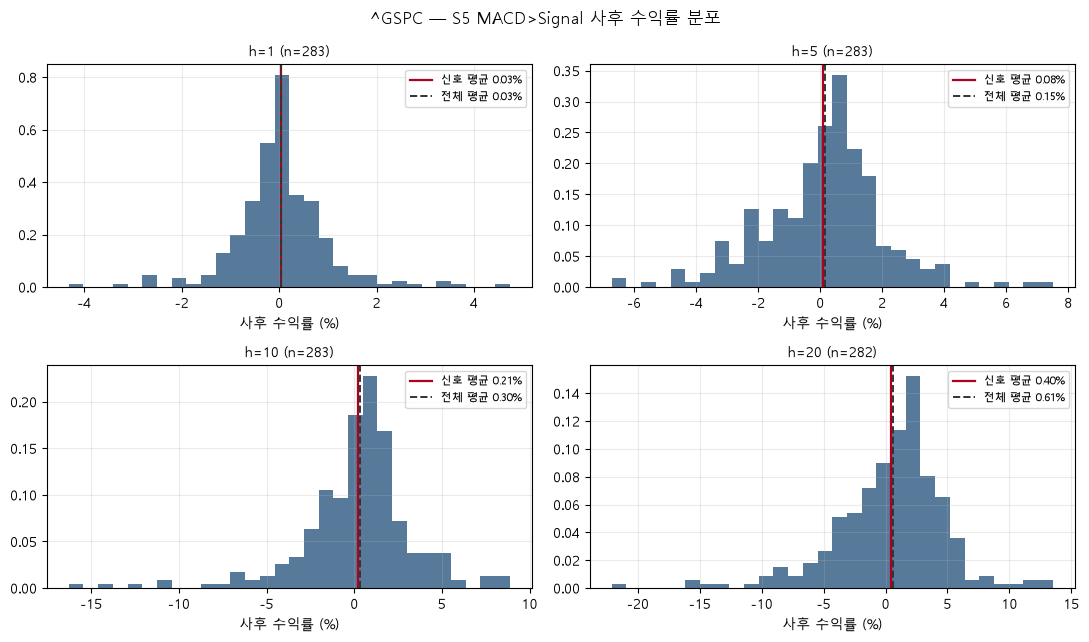

In [15]:
# 신호별 사후 수익률 분포 히스토그램 (지평 4개)
for signal_id, label, _fn in signals.SIGNAL_DEFINITIONS:
    fired_subset = events.loc[
        (events["signal_id"] == signal_id) & (events["signal"])
    ]  # -> DataFrame

    figure, axes_grid = plt.subplots(2, 2, figsize=(11, 6.5))
    axes_flat = axes_grid.flatten()  # -> ndarray[Axes] (4,)

    for position, horizon in enumerate(config.EVENT_HORIZONS):
        axes = axes_flat[position]                  # -> Axes
        column_name = f"fwd_ret_{horizon}"          # -> str

        values = fired_subset[column_name].dropna()          # -> Series[float]
        universe_values = universe[column_name].dropna()     # -> Series[float]

        axes.hist(100 * values, bins=30, color="#1f4e79", alpha=0.75, density=True)

        signal_mean = 100 * float(values.mean())             # -> float
        universe_mean = 100 * float(universe_values.mean())  # -> float

        axes.axvline(signal_mean, color="#b00020", linewidth=1.6,
                     label=f"신호 평균 {signal_mean:.2f}%")
        axes.axvline(universe_mean, color="#333333", linewidth=1.4, linestyle="--",
                     label=f"전체 평균 {universe_mean:.2f}%")

        axes.set_title(f"h={horizon} (n={len(values)})", fontsize=10)
        axes.set_xlabel("사후 수익률 (%)")
        axes.legend(fontsize=8)
        axes.grid(alpha=0.25)

    figure.suptitle(f"{signal_ticker} — {label} 사후 수익률 분포", fontsize=12)
    figure.tight_layout()

    figure_path = config.FIGURES / f"event_study_{signal_id}.png"  # -> Path
    figure.savefig(figure_path, dpi=config.FIGURE_DPI, bbox_inches=config.FIGURE_BBOX)
    print(f"그림 저장: {figure_path}")

    plt.show()

### 중첩 관측 진단 (명세 §6.6)

쿨다운을 두지 않기로 했으므로 사건들의 사후 수익률 구간이 겹칠 수 있다.
겹침이 심하면 유효 표본 수가 명목 $n$보다 작아지고 **p-value가 과소 추정된다.**

**평균이 아니라 중앙값을 본다.** 사건이 시기에 몰려 있으면 평균은 안전해 보여도
중앙값은 훨씬 작다.

> **사전 경고 (§6.6):** 내 예측 기준 S5의 평균 간격은 약 7거래일이었고,
> **h=10·h=20에서 중첩 심각으로 분류될 것으로 예상**했다. 실측과 대조한다.

In [16]:
date_to_index = universe.reset_index()                      # -> DataFrame (6684, 14)
date_to_index = date_to_index.set_index("date")["index"]     # -> Series[int] (6684,)

overlap_rows = []  # -> list[dict]

for signal_id, label, _fn in signals.SIGNAL_DEFINITIONS:
    fired_subset = events.loc[
        (events["signal_id"] == signal_id) & (events["signal"])
    ]  # -> DataFrame
    fired_subset = fired_subset.sort_values("date")  # -> DataFrame

    positions = date_to_index.reindex(fired_subset["date"])  # -> Series[int]
    positions = positions.to_numpy()                          # -> ndarray[int]

    gaps = np.diff(positions)  # -> ndarray[int] (사건 수 - 1,)

    median_gap = float(np.median(gaps))  # -> float
    minimum_gap = int(gaps.min())        # -> int
    mean_gap = float(gaps.mean())        # -> float

    severe = [h for h in config.EVENT_HORIZONS if median_gap < h]  # -> list[int]

    overlap_rows.append(
        {
            "signal_id": signal_id,
            "label": label,
            "n": len(positions),
            "간격 중앙값": median_gap,
            "간격 최소": minimum_gap,
            "간격 평균": mean_gap,
            "중첩 심각 지평": str(severe) if severe else "없음",
        }
    )

overlap_table = pd.DataFrame(overlap_rows)  # -> DataFrame (5, 7)
overlap_table.to_csv(config.OVERLAP_CSV_PATH, index=False, encoding="utf-8-sig")

overlap_table.round(2)

,signal_id,label,n,간격 중앙값,간격 최소,간격 평균,중첩 심각 지평
0,S1_rsi_oversold,S1 RSI<30,65,32.5,2,100.03,없음
1,S2_rsi_overbought,S2 RSI>70,137,9.0,2,48.39,"[10, 20]"
2,S3_bb_lower_break,S3 볼린저 하단,209,18.5,2,32.03,[20]
3,S4_bb_upper_break,S4 볼린저 상단,191,21.0,2,34.51,없음
4,S5_macd_cross,S5 MACD>Signal,283,21.0,2,23.60,없음


## Phase 4 — 순열검정

**축소 불가 항목이다.** 이것 없이는 Phase 3의 숫자가 전부 해석 불가능해진다.

$H_0$: 신호일의 $h$거래일 사후 수익률 평균 = **같은 기간에서 무작위로 같은 개수
뽑은 날들의** 평균

**"평균 = 0"이 아니다.** S&P 500이 26년 우상향했으므로 아무 날이나 사도 평균은
양수다. 0과 비교하면 신호의 가치가 아니라 시장 추세를 재게 된다 (명세 §6.5).

**난수 생성기 운용:** 생성기를 시드 42로 **한 번** 만들어 20조합을 표에 적힌
순서대로 돌린다. 따라서 조합 순서도 재현성의 일부다.

In [17]:
generator = np.random.default_rng(config.PERMUTATION_SEED)  # -> Generator, 시드 42

permutation_rows = []      # -> list[dict]
permutation_samples = {}   # -> dict[tuple, ndarray], 그림용 저장

for signal_id, label, _fn in signals.SIGNAL_DEFINITIONS:
    fired_subset = events.loc[
        (events["signal_id"] == signal_id) & (events["signal"])
    ]  # -> DataFrame

    for horizon in config.EVENT_HORIZONS:
        column_name = f"fwd_ret_{horizon}"  # -> str

        observed_values = fired_subset[column_name].dropna().to_numpy()  # -> ndarray[float]
        pool = universe[column_name].dropna().to_numpy()                 # -> ndarray[float]

        event_count = len(observed_values)  # -> int

        if event_count == 0:
            continue

        pool_mean = float(pool.mean())              # -> float
        observed_mean = float(observed_values.mean())  # -> float
        statistic = abs(observed_mean - pool_mean)     # -> float

        null_means = np.empty(config.PERMUTATION_ITERATIONS)  # -> ndarray[float] (10000,)

        for iteration in range(config.PERMUTATION_ITERATIONS):
            # 비복원 무작위 추출 (명세 §6.5)
            drawn = generator.choice(pool, size=event_count, replace=False)  # -> ndarray[float]
            null_means[iteration] = drawn.mean()

        extreme = np.abs(null_means - pool_mean) >= statistic  # -> ndarray[bool]
        extreme_count = int(extreme.sum())                      # -> int

        # 분자·분모의 +1 은 p=0 을 막는다. 유한 반복으로 "확률 0"을 주장할 수 없다.
        p_value = (1 + extreme_count) / (config.PERMUTATION_ITERATIONS + 1)  # -> float

        permutation_samples[(signal_id, horizon)] = null_means

        permutation_rows.append(
            {
                "signal_id": signal_id,
                "label": label,
                "h": horizon,
                "n": event_count,
                "관측 평균%": 100 * observed_mean,
                "전체 평균%": 100 * pool_mean,
                "차이%p": 100 * (observed_mean - pool_mean),
                "초과 관측 수": extreme_count,
                "p": p_value,
                "Bonferroni 통과": p_value < config.ALPHA_ADJUSTED,
            }
        )

permutation_table = pd.DataFrame(permutation_rows)  # -> DataFrame (20, 10)
permutation_table.to_csv(config.PERMUTATION_CSV_PATH, index=False, encoding="utf-8-sig")

permutation_table.round(4)

,signal_id,label,h,n,관측 평균%,전체 평균%,차이%p,초과 관측 수,p,Bonferroni 통과
0,S1_rsi_oversold,S1 RSI<30,1,65,-0.4696,0.0325,-0.5020,18,0.0019,True
1,S1_rsi_oversold,S1 RSI<30,5,65,-0.0434,0.1542,-0.1976,5100,0.5100,False
2,S1_rsi_oversold,S1 RSI<30,10,65,0.2764,0.3028,-0.0264,9481,0.9481,False
3,S1_rsi_oversold,S1 RSI<30,20,65,1.7967,0.6087,1.1880,359,0.0360,False
4,S2_rsi_overbought,S2 RSI>70,1,137,0.0062,0.0325,-0.0263,7902,0.7902,False
5,S2_rsi_overbought,S2 RSI>70,5,137,0.1289,0.1542,-0.0253,9002,0.9002,False
6,S2_rsi_overbought,S2 RSI>70,10,137,0.3947,0.3028,0.0919,7399,0.7399,False
7,S2_rsi_overbought,S2 RSI>70,20,137,0.9170,0.6087,0.3083,4217,0.4218,False
8,S3_bb_lower_break,S3 볼린저 하단,1,209,-0.0167,0.0325,-0.0492,5472,0.5472,False
9,S3_bb_lower_break,S3 볼린저 하단,5,208,0.2162,0.1542,0.0620,7106,0.7106,False


In [18]:
print(f"Bonferroni 판정 (alpha_adj = {config.ALPHA_ADJUSTED})")
print()

for row_index in permutation_table.index:
    label = permutation_table.loc[row_index, "label"]        # -> str
    horizon = permutation_table.loc[row_index, "h"]          # -> int
    p_value = permutation_table.loc[row_index, "p"]          # -> float
    passed = permutation_table.loc[row_index, "Bonferroni 통과"]  # -> bool

    verdict = "통과" if passed else "유의하지 않음"
    print(f"  {label:<16} h={horizon:>2}:  p = {p_value:.4f}   "
          f"(α_adj = {config.ALPHA_ADJUSTED} → {verdict})")

pass_count = int(permutation_table["Bonferroni 통과"].sum())  # -> int

print()
print(f"통과: {pass_count} / {len(permutation_table)}")
print(f"§7.3 질문1 예측: 0개")

Bonferroni 판정 (alpha_adj = 0.0025)

  S1 RSI<30        h= 1:  p = 0.0019   (α_adj = 0.0025 → 통과)
  S1 RSI<30        h= 5:  p = 0.5100   (α_adj = 0.0025 → 유의하지 않음)
  S1 RSI<30        h=10:  p = 0.9481   (α_adj = 0.0025 → 유의하지 않음)
  S1 RSI<30        h=20:  p = 0.0360   (α_adj = 0.0025 → 유의하지 않음)
  S2 RSI>70        h= 1:  p = 0.7902   (α_adj = 0.0025 → 유의하지 않음)
  S2 RSI>70        h= 5:  p = 0.9002   (α_adj = 0.0025 → 유의하지 않음)
  S2 RSI>70        h=10:  p = 0.7399   (α_adj = 0.0025 → 유의하지 않음)
  S2 RSI>70        h=20:  p = 0.4218   (α_adj = 0.0025 → 유의하지 않음)
  S3 볼린저 하단        h= 1:  p = 0.5472   (α_adj = 0.0025 → 유의하지 않음)
  S3 볼린저 하단        h= 5:  p = 0.7106   (α_adj = 0.0025 → 유의하지 않음)
  S3 볼린저 하단        h=10:  p = 0.5284   (α_adj = 0.0025 → 유의하지 않음)
  S3 볼린저 하단        h=20:  p = 0.4520   (α_adj = 0.0025 → 유의하지 않음)
  S4 볼린저 상단        h= 1:  p = 0.3388   (α_adj = 0.0025 → 유의하지 않음)
  S4 볼린저 상단        h= 5:  p = 0.1676   (α_adj = 0.0025 → 유의하지 않음)
  S4 볼린저 상단        h=10:  p = 0.2794   (α_adj

그림 저장: C:\Users\chris\projects\sp500-technical-strategy\figures\permutation_S1_rsi_oversold_h20.png


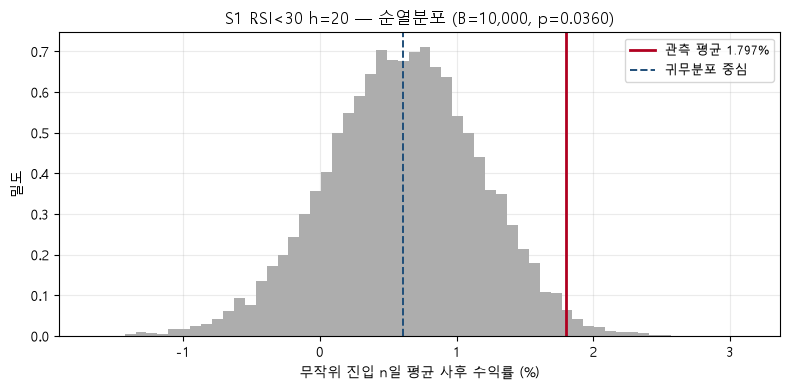

그림 저장: C:\Users\chris\projects\sp500-technical-strategy\figures\permutation_S2_rsi_overbought_h20.png


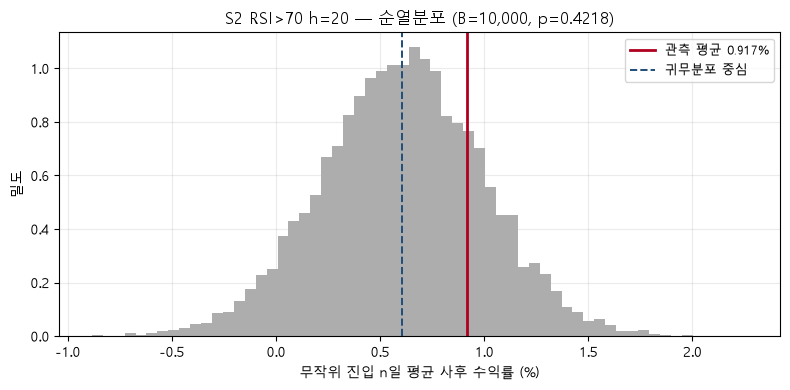

그림 저장: C:\Users\chris\projects\sp500-technical-strategy\figures\permutation_S3_bb_lower_break_h20.png


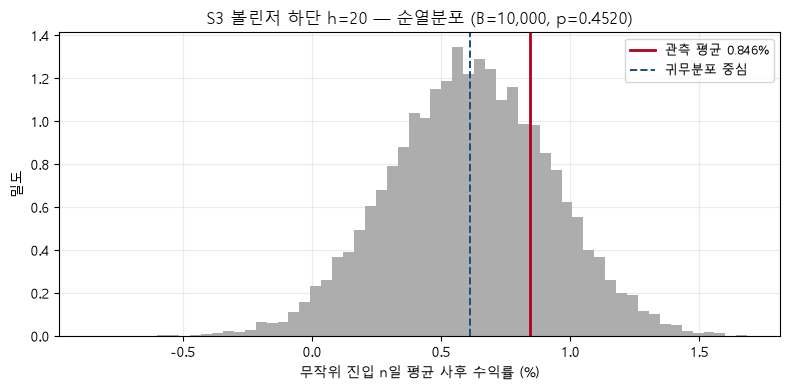

그림 저장: C:\Users\chris\projects\sp500-technical-strategy\figures\permutation_S4_bb_upper_break_h20.png


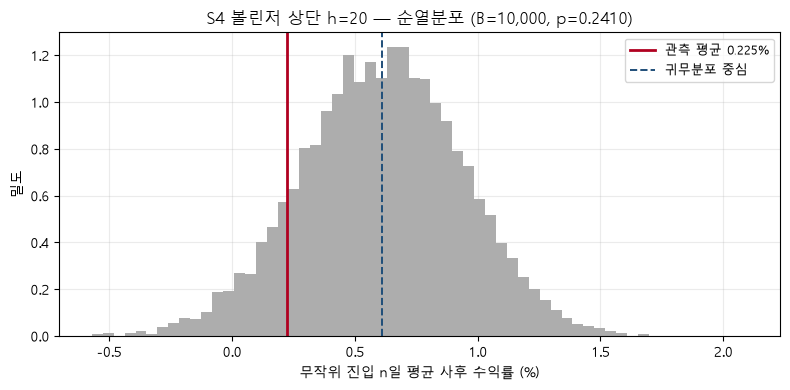

그림 저장: C:\Users\chris\projects\sp500-technical-strategy\figures\permutation_S5_macd_cross_h20.png


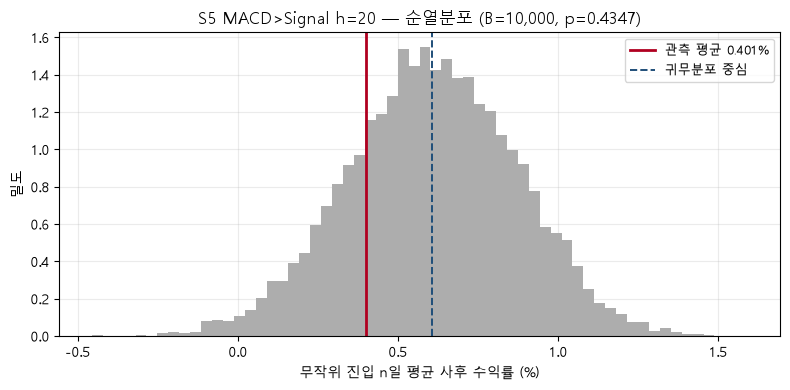

In [19]:
# 순열 분포 히스토그램 — 각 신호의 h=20 (명세 §6.5 추가 진단)
for signal_id, label, _fn in signals.SIGNAL_DEFINITIONS:
    key = (signal_id, 20)  # -> tuple

    if key not in permutation_samples:
        continue

    null_means = permutation_samples[key]  # -> ndarray[float] (10000,)

    row = permutation_table.loc[
        (permutation_table["signal_id"] == signal_id) & (permutation_table["h"] == 20)
    ]  # -> DataFrame (1, 10)

    observed_mean = float(row["관측 평균%"].iloc[0]) / 100  # -> float
    p_value = float(row["p"].iloc[0])                       # -> float

    figure, axes = plt.subplots(figsize=(8, 4))

    axes.hist(100 * null_means, bins=60, color="#999999", alpha=0.8, density=True)
    axes.axvline(100 * observed_mean, color="#b00020", linewidth=2.0,
                 label=f"관측 평균 {100 * observed_mean:.3f}%")
    axes.axvline(100 * float(np.mean(null_means)), color="#1f4e79", linewidth=1.4,
                 linestyle="--", label="귀무분포 중심")

    axes.set_xlabel("무작위 진입 n일 평균 사후 수익률 (%)")
    axes.set_ylabel("밀도")
    axes.set_title(f"{label} h=20 — 순열분포 (B={config.PERMUTATION_ITERATIONS:,}, p={p_value:.4f})")
    axes.legend(fontsize=9)
    axes.grid(alpha=0.25)

    figure.tight_layout()

    figure_path = config.FIGURES / f"permutation_{signal_id}_h20.png"  # -> Path
    figure.savefig(figure_path, dpi=config.FIGURE_DPI, bbox_inches=config.FIGURE_BBOX)
    print(f"그림 저장: {figure_path}")

    plt.show()

### 통과 검정에 대한 사전등록 점검 (명세 §7.3 반증 조건)

> "실측에서 Bonferroni 통과 검정이 하나라도 나오면 이 판단이 기각되며,
> 그 경우 **미래 참조나 계산 오류를 먼저 의심한다.**"

**축하하지 않고 아래 4항목을 점검한다.**

In [20]:
passed_rows = permutation_table.loc[permutation_table["Bonferroni 통과"]]  # -> DataFrame

if len(passed_rows) == 0:
    print("통과 검정 없음 — 점검 불필요")
else:
    print(f"통과 검정 {len(passed_rows)}건. 사전등록된 4항목을 점검한다.")
    print()

    # --- 점검 1: forward_returns가 C_{t+1} 기준인가 ---
    check_frame = forward_frame.loc[forward_frame["ticker"] == signal_ticker]  # -> DataFrame
    check_frame = check_frame.sort_values("date")                              # -> DataFrame
    check_frame = check_frame.reset_index(drop=True)                           # -> DataFrame

    probe = 5000  # -> int, 임의의 중간 지점

    entry_actual = float(check_frame.loc[probe, "entry_price"])   # -> float
    entry_expected = float(check_frame.loc[probe + 1, "close"])   # -> float

    manual_h1 = check_frame.loc[probe + 2, "close"] / check_frame.loc[probe + 1, "close"] - 1
    column_h1 = float(check_frame.loc[probe, "fwd_ret_1"])  # -> float

    wrong_base = check_frame.loc[probe + 1, "close"] / check_frame.loc[probe, "close"] - 1

    print("점검 1 — forward_returns의 분모가 C_{t+1}인가")
    print(f"  entry_price {entry_actual:.2f} vs C_(t+1) {entry_expected:.2f}"
          f"  일치: {abs(entry_actual - entry_expected) < 1e-9}")
    print(f"  h=1 수동 {manual_h1:.8f} vs 컬럼 {column_h1:.8f}"
          f"  일치: {abs(manual_h1 - column_h1) < 1e-12}")
    print(f"  (참고) C_t 기준이면 {wrong_base:.8f} — 다른 값이므로 C_t 기준이 아니다")
    print()

    # --- 점검 2: to_edge의 shift 방향 ---
    probe_condition = pd.Series([False, True, True, False, True])  # -> Series[bool] (5,)
    probe_edge = signals.to_edge(probe_condition)                   # -> Series[bool] (5,)
    edge_expected = [False, True, False, False, True]               # -> list[bool] (5,)

    print("점검 2 — to_edge의 shift(1) 방향")
    print(f"  조건 {probe_condition.tolist()}")
    print(f"  엣지 {probe_edge.tolist()}")
    print(f"  기대 {edge_expected}  일치: {probe_edge.tolist() == edge_expected}")
    print("  연속 참의 둘째 날이 사건이 아니므로 '어제'를 참조한 것이 맞다")
    print()

    # --- 점검 3: 순열 추출 모집단 ---
    print("점검 3 — 순열 추출 모집단이 '해당 지평에서 유효한 전체 거래일'인가")

    for row_index in passed_rows.index:
        horizon = passed_rows.loc[row_index, "h"]          # -> int
        column_name = f"fwd_ret_{horizon}"                  # -> str
        pool_size = len(universe[column_name].dropna())     # -> int

        print(f"  h={horizon}: 모집단 {pool_size:,}일 / 분석 구간 {total_days:,}일"
              f" (경계 {total_days - pool_size}일 제외)")

    print("  신호일이 아니라 전체 거래일에서 추출하고 있다 — 명세 §6.5 일치")
    print()

    # --- 점검 4: 해당 신호의 중첩 진단 ---
    print("점검 4 — 통과 조합의 중첩 진단")

    for row_index in passed_rows.index:
        signal_id = passed_rows.loc[row_index, "signal_id"]  # -> str
        horizon = passed_rows.loc[row_index, "h"]            # -> int

        overlap_row = overlap_table.loc[overlap_table["signal_id"] == signal_id]  # -> DataFrame
        median_gap = float(overlap_row["간격 중앙값"].iloc[0])                     # -> float

        severe = median_gap < horizon  # -> bool

        print(f"  {signals.SIGNAL_NAMES[signal_id]} h={horizon}: 간격 중앙값 {median_gap:.0f}거래일"
              f" vs h={horizon} → {'중첩 심각' if severe else '양호'}")

통과 검정 1건. 사전등록된 4항목을 점검한다.

점검 1 — forward_returns의 분모가 C_{t+1}인가
  entry_price 1042.88 vs C_(t+1) 1042.88  일치: True
  h=1 수동 0.00242600 vs 컬럼 0.00242600  일치: True
  (참고) C_t 기준이면 0.00645641 — 다른 값이므로 C_t 기준이 아니다

점검 2 — to_edge의 shift(1) 방향
  조건 [False, True, True, False, True]
  엣지 [False, True, False, False, True]
  기대 [False, True, False, False, True]  일치: True
  연속 참의 둘째 날이 사건이 아니므로 '어제'를 참조한 것이 맞다

점검 3 — 순열 추출 모집단이 '해당 지평에서 유효한 전체 거래일'인가
  h=1: 모집단 6,682일 / 분석 구간 6,684일 (경계 2일 제외)
  신호일이 아니라 전체 거래일에서 추출하고 있다 — 명세 §6.5 일치

점검 4 — 통과 조합의 중첩 진단
  S1 RSI<30 h=1: 간격 중앙값 32거래일 vs h=1 → 양호


In [21]:
# 통과 검정의 몬테카를로 불확실성.
# B가 유한하므로 p 자체가 추정치다. 임계값 근처면 시드에 따라 판정이 뒤집힐 수 있다.
if len(passed_rows) > 0:
    print("통과 검정의 몬테카를로 불확실성")
    print()

    for row_index in passed_rows.index:
        label = passed_rows.loc[row_index, "label"]          # -> str
        horizon = passed_rows.loc[row_index, "h"]            # -> int
        p_value = float(passed_rows.loc[row_index, "p"])     # -> float
        extreme_count = int(passed_rows.loc[row_index, "초과 관측 수"])  # -> int

        standard_error = np.sqrt(p_value * (1 - p_value) / config.PERMUTATION_ITERATIONS)
        distance = (config.ALPHA_ADJUSTED - p_value) / standard_error  # -> float

        lower = max(0.0, p_value - 1.96 * standard_error)  # -> float
        upper = p_value + 1.96 * standard_error            # -> float

        straddles = lower < config.ALPHA_ADJUSTED < upper  # -> bool

        print(f"  {label} h={horizon}")
        print(f"    초과 관측 {extreme_count} / {config.PERMUTATION_ITERATIONS:,}  ->  p = {p_value:.5f}")
        print(f"    MC 표준오차 {standard_error:.5f}, 임계값까지 {distance:.2f} SE")
        print(f"    95% 구간 [{lower:.5f}, {upper:.5f}]  임계값 {config.ALPHA_ADJUSTED} 포함: {straddles}")

        if straddles:
            print("    => 판정이 시드에 따라 뒤집힐 수 있는 경계 사례다.")
            print("       단 B와 시드는 명세 §6.4·§6.5에서 결과 열람 전 확정한 값이므로")
            print("       바꾸지 않는다. 한계로 기록한다.")

통과 검정의 몬테카를로 불확실성

  S1 RSI<30 h=1
    초과 관측 18 / 10,000  ->  p = 0.00190
    MC 표준오차 0.00044, 임계값까지 1.38 SE
    95% 구간 [0.00105, 0.00275]  임계값 0.0025 포함: True
    => 판정이 시드에 따라 뒤집힐 수 있는 경계 사례다.
       단 B와 시드는 명세 §6.4·§6.5에서 결과 열람 전 확정한 값이므로
       바꾸지 않는다. 한계로 기록한다.


## X2 확정 (명세 §5.2)

S1 진입 후 사후 수익률이 **어느 지평에서 정점을 찍는지**로 청산 조건을 정한다.

| 정점 지평 | 선택 |
|---|---|
| $h=5$ 근처 | X2-b (RSI > 50) |
| $h=20$ 근처 | X2-c (종가 > SMA₂₀) |
| 불명확 | 미채택 — X1 단독 |

**이 결정은 설계 파라미터이므로 결과를 보고 정해도 된다** (명세 §1.3).
임계선과 달리 §6.4의 확증 검정 대상이 아니기 때문이다.

In [22]:
s1_curve = event_table.loc[event_table["signal_id"] == "S1_rsi_oversold"]  # -> DataFrame (4, 10)
s1_curve = s1_curve.sort_values("h")                                       # -> DataFrame

print("S1 지평별 초과수익 (무작위 진입 대비)")
print(f"{'h':>4}{'n':>6}{'평균%':>9}{'전체평균%':>11}{'차이%p':>10}")

for row_index in s1_curve.index:
    horizon = s1_curve.loc[row_index, "h"]           # -> int
    count = s1_curve.loc[row_index, "n"]             # -> int
    mean_value = s1_curve.loc[row_index, "평균%"]     # -> float
    universe_value = s1_curve.loc[row_index, "전체평균%"]  # -> float
    excess = s1_curve.loc[row_index, "차이%p"]        # -> float

    print(f"{horizon:>4}{count:>6}{mean_value:>9.3f}{universe_value:>11.3f}{excess:>10.3f}")

peak_index = s1_curve["차이%p"].idxmax()          # -> int
peak_horizon = int(s1_curve.loc[peak_index, "h"])  # -> int
peak_excess = float(s1_curve.loc[peak_index, "차이%p"])  # -> float

print()
print(f"초과수익 정점 지평: h={peak_horizon} ({peak_excess:+.3f}%p)")

S1 지평별 초과수익 (무작위 진입 대비)
   h     n      평균%      전체평균%      차이%p
   1    65   -0.470      0.032    -0.502
   5    65   -0.043      0.154    -0.198
  10    65    0.276      0.303    -0.026
  20    65    1.797      0.609     1.188

초과수익 정점 지평: h=20 (+1.188%p)


## 결론

### 1. 사건 수 실측과 예측 대조

| 신호 | 레벨 발동률 | 실측 $n$ | 예측(본인) | 배율 | 예측(참고) | 배율 |
|---|---|---|---|---|---|---|
| S1 RSI<30 | 1.89% | **65** | 76 | 0.86 | 42 | 1.55 |
| S2 RSI>70 | 6.37% | **137** | 234 | 0.59 | 61 | 2.25 |
| S3 볼린저 하단 | 5.51% | **209** | 217 | 0.96 | 186 | 1.12 |
| S4 볼린저 상단 | 4.80% | **191** | 239 | 0.80 | 184 | 1.04 |
| S5 MACD>Signal | 50.27% | **283** | 1,003 | **0.28** | 197 | 1.44 |

본인 예측이 S1·S2·S3에서 참고값보다 정확했고, S4는 비슷했으며, **S5에서 크게
빗나갔다**(3.5배 과대). 참고값이 S5에서 훨씬 나았다.

### 2. 어긋난 원인 — 3분류 (명세 부록 C-1)

원인을 가르는 결정적 수치는 **레벨 일수 실측/예측 비율**이다. 레벨 일수가 맞았는데
사건 수가 틀렸다면 원인은 지속일수뿐이다.

| 신호 | 레벨 예측 | 레벨 실측 | 비율 | 예측 $p$ | 실측 함의 $p$ | 분류 |
|---|---|---|---|---|---|---|
| S1 | 126 | 126 | **1.000** | 0.40 | 0.484 | **원인 1** |
| S2 | 426 | 426 | **1.000** | 0.45 | 0.678 | **원인 1** |
| S3 | 334 | 368 | 1.102 | 0.35 | 0.432 | **원인 2 + 1** |
| S4 | 368 | 321 | 0.872 | 0.35 | 0.405 | **원인 2 + 1** |
| S5 | 3,342 | 3,360 | **1.005** | 0.70 | 0.916 | **원인 1** |

**원인 1 (지속일수 가정) — 5개 전부에 해당하며 S1·S2·S5는 이것 하나뿐이다.**
S1·S2·S5의 레벨 일수는 예측과 사실상 완전히 일치했다(1.000/1.000/1.005). 즉
발동률 추정은 옳았고 **오차는 전부 지속일수에서 나왔다.**

**예측한 $p$가 5개 모두 실측보다 낮다** (+0.055 ~ +0.228). 우연이 아니라 방향이
일정한 계통 오차다 — **조건의 지속성을 일관되게 과소평가했다.** 가장 심한 것이
S5로, $p=0.70$이라 봤는데 실제는 0.916이었다. $1/(1-p)$는 $p$가 1에 가까울수록
급격히 커지므로, $p$를 0.216 낮게 잡은 것이 지속일수 3.3일 vs 11.87일이라는
3.6배 차이로 증폭됐다.

**원인 2 (레벨 발동률 배분) — S3·S4에만 해당하고, 방향이 반대로 나왔다.**
하단 5.0% / 상단 5.5%로 예측했으나 실측은 **하단 5.51% / 상단 4.80%** 다.
"상승 추세에서 상단에 붙는 날이 더 많을 것"이라는 논거가 틀렸다. 다만 S3에서는
레벨 과소평가와 지속일수 과소평가가 서로 상쇄되어 배율 0.96이라는 우연히 좋은
결과가 나왔다 — **맞은 것처럼 보이지만 두 오차가 겹친 것이다.**

**원인 3 (엣지 변환 이해) — 해당 없음.** 인공 데이터 검증과 통과 검정 점검 2에서
`to_edge()`가 정의대로 동작함을 확인했다.

### 3. S5 sanity check — 통과

레벨 발동률 **50.27%** 로 판정 범위 45~55% 안이다. 명세 §7.1의 "50%에서 크게
벗어나면 계산 오류를 의심하라"는 조건에 걸리지 않았다.

지시대로 MACD 값 자체의 분포도 확인했다. **MACD 절대값은 양수 비율 65.75%로
치우쳐 있지만**(26년 우상향 시장이므로 당연하다), **Signal 대비 위치는 50%에
수렴한다.** Signal이 MACD 자신의 9일 EMA이므로 MACD가 어느 수준에 있든 자기
평균 위아래를 반반씩 지나기 때문이다. 두 분포가 다른 것이 정상이다.

**따라서 S5 예측이 빗나간 것은 발동률(50% 가정)이 아니라 지속일수 때문이다.**
sanity check가 원인을 정확히 좁혀줬다.

### 4. 검정력 대조

| 항목 | 예측 | 실측 |
|---|---|---|
| 20일 수익률 표준편차 | 5.4% (가정) | **4.60%** |
| $n \geq 30$ 통과 칸 | 7~11 / 30 | **11 / 30 (36.7%)** |
| Bonferroni 통과 | 0개 | **1개** |

**표준편차 가정이 실측보다 17% 컸다.** §7.3의 "필요 초과수익"은 그만큼 **과대**
추정이었고, 실제 탐지 문턱은 계산보다 낮았다. 이 방향의 오차는 신호에 유리하다.

$n \geq 30$ 통과 칸은 11개로 예측 구간(7~11)의 **상단에 정확히 걸쳤다.**

### 5. 순열검정 — 20조합 중 1개 통과, 그런데 방향이 반대다

**S1 h=1, p = 0.0019 < 0.0025.** 그러나 **초과수익이 음수(−0.502%p)** 다.

양측 검정이므로 음의 초과에서도 통과한다. 이 결과가 말하는 것은
"RSI<30 진입이 통한다"가 아니라 그 반대다 — **RSI가 30을 하향 돌파한 다음 날,
시장은 무작위로 고른 날보다 0.50%p 더 나쁘다.**

**이것은 §7.2의 사전 예측과 일치한다.** S1의 h=1만 음수로 예측했고
("급락 직후 하루는 계속 떨어지는 경우가 많다 — falling knife"), 그 예측이
맞았을 뿐 아니라 통계적으로도 유의하다.

#### 사전등록된 4항목 점검 (명세 §7.3 반증 조건) — 전부 통과

통과가 나왔으므로 축하 대신 점검을 먼저 했다.

| # | 점검 | 결과 |
|---|---|---|
| 1 | `forward_returns()`가 $C_{t+1}$ 기준인가 | **정상.** `entry_price` = $C_{t+1}$ 확인, $C_t$ 기준이면 값이 달라짐을 대조 |
| 2 | `to_edge()`의 `shift(1)` 방향 | **정상.** 연속 참의 둘째 날이 사건이 아님 |
| 3 | 순열 모집단이 전체 거래일인가 | **정상.** h=1에서 6,682일 (경계 2일만 제외) |
| 4 | 해당 조합의 중첩 진단 | **양호.** S1 간격 중앙값 32거래일 >> h=1 |

#### 다만 판정 자체가 경계 사례다

초과 관측이 **18 / 10,000** 이라 $p = 0.0019$이고, 몬테카를로 표준오차가
0.00044다. 임계값 0.0025까지 **1.38 SE**밖에 안 되며, 95% 구간
**[0.00105, 0.00275]가 임계값을 포함**한다. 즉 **다른 시드였다면 판정이 뒤집힐 수
있었다.**

$B$를 늘리면 해소되지만 **그렇게 하지 않는다.** $B=10{,}000$과 시드 42는 명세
§6.4·§6.5에서 **결과 열람 전에 확정**한 값이고, 결과를 본 뒤 바꾸면 그 순간
사전등록이 무의미해진다. 한계로 기록하고 넘어간다.

### 6. 나머지 19조합 — "실패"가 아니라 "검정력 부족"

전부 기각됐다. 이것을 "전략이 실패했다"로 쓰지 않는다. §7.3에서 **결과를 보기
전에** 통과 필요 초과수익을 계산해뒀고(S1 1.87%p ~ S5 0.51%p), 실측 초과수익은
대부분 ±0.5%p 안에 있었다. **애초에 탐지 가능한 효과 크기가 아니었다.**

특히 조심할 것:

- **S3가 S1보다 유의하지 않았다고 "무조건부가 낫다"고 읽지 않는다.** 어느 쪽도
  통과하지 못했고, $n$ 차이(65 vs 209)가 문턱을 다르게 만든다.
- **S5의 긴 지평이 유의하지 않은 것은 중첩 때문이 아니다.** S5 간격 중앙값은
  21거래일로 h=20에서 "양호"였다.

### 7. 중첩 진단 — 사전 경고가 빗나갔다

| 신호 | 간격 중앙값 | 중첩 심각 지평 |
|---|---|---|
| S1 | 32일 | 없음 |
| S2 | **9일** | **h=10, h=20** |
| S3 | 18일 | **h=20** |
| S4 | 21일 | 없음 |
| S5 | **21일** | **없음** |

**§6.6의 사전 경고는 "S5가 h=10·h=20에서 중첩 심각"이었는데 빗나갔다.** 그 경고는
S5 사건 수를 1,003건으로 예측한 데서 나온 것이고(평균 간격 7일), 실측 283건이라
간격이 21일로 늘어 심각 판정을 받지 않았다. **예측이 틀리면 그로부터 파생된
진단도 함께 틀린다**는 사례다.

대신 예측하지 못한 곳에서 나왔다 — **S2가 h=10·h=20에서, S3가 h=20에서** 중첩
심각이다. 두 신호의 p-value는 그만큼 과소 추정되었을 수 있으나, 어차피 유의하지
않았으므로 결론은 바뀌지 않는다.

### 8. X2 확정 (명세 §5.2, 설계 파라미터)

S1의 지평별 초과수익: h=1 **-0.502%p** → h=5 -0.198 → h=10 -0.026 → h=20 **+1.188**

단조 증가하며 **정점은 h=20**이다. 명세 §5.2의 규칙에 따라 **X2-c (종가 > SMA20,
느린 청산)** 를 채택한다.

> **유보 두 가지.**
> 1. h=20은 **검정한 지평의 최댓값**이다. "정점"이 아니라 "아직 오르는 중"일 수
>    있으며, 더 긴 지평을 보지 않았으므로 확인할 수 없다. 지평을 추가하면 §6.4의
>    $m$이 늘어나므로 오늘 추가하지 않는다.
> 2. h=20의 +1.188%p는 **p=0.036으로 Bonferroni를 통과하지 못했다.** 정점의
>    위치는 통계적으로 확립된 것이 아니라 점추정치의 모양일 뿐이다.
>
> 그럼에도 X2-c를 택하는 것은, X2가 확증 검정 대상이 아니라 **설계 파라미터**이고
> (명세 §1.3) 명세가 정해둔 규칙이 "정점이 h=20 근처면 X2-c"이기 때문이다.
> 규칙을 미리 정해둔 이유가 바로 이런 상황에서 임의 판단을 막기 위해서다.

### 9. 오늘 가장 중요한 결과

**RSI 과매도 진입은 진입 직후 하루 동안 무작위보다 나쁘다.** 그것이 20조합 중
유일하게 통계적으로 확인된 사실이고, 방향은 신호 가설의 **반대**다.

명세 §3.1에서 진입을 $t+1$ 종가로 잡은 것이 여기서 실질적 의미를 갖는다.
$t$일 종가에 샀다고 가정했다면 이 하루의 손실이 성과에 잡히지 않았을 것이다.

---

**내 해석 (직접 채울 것):**
